# Evaluation — claude-opus-4-8

Compares **two inference strategies** for `claude-opus-4-8` against manually labeled ground truth.

| Method | Description |
|---|---|
| **Batched** | 10 blocks per API call with a 3-block sliding context window |
| **Whole-doc** | All blocks in a single API call — model sees full document structure |

Sections:
1. Accuracy summary — both methods side by side
2. Per-sample accuracy chart
3. Confusion matrices
4. Precision / Recall / F1 per label
5. Mislabeled blocks

## Setup

In [1]:
MODEL_NAME    = "claude-opus-4-8"
COLOR_BATCH   = "#7c3aed"   # deep purple  — batched
COLOR_WHOLE   = "#a855f7"   # lighter purple — whole-doc
CMAP_BATCH    = "Purples"
CMAP_WHOLE    = "RdPu"

In [2]:
import sys
sys.path.insert(0, "..")

from evaluate import extract_gold, evaluate_sample, match, LABELS, SHORT, LLM_DIR, MANUAL_DIR, NO_MATCH
import json
from collections import defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="ticks", palette="muted")
plt.rcParams.update({
    "figure.facecolor":"white", "axes.facecolor":"white",
    "axes.edgecolor":"#555555", "axes.linewidth":0.8,
    "grid.color":"#dddddd",    "grid.linewidth":0.5,
    "text.color":"#111111",    "axes.labelcolor":"#111111",
    "xtick.color":"#111111",   "ytick.color":"#111111",
    "font.size":11, "axes.titlesize":13, "axes.labelsize":11,
    "xtick.labelsize":10, "ytick.labelsize":10,
    "legend.fontsize":10, "legend.frameon":True, "legend.edgecolor":"#cccccc",
    "figure.dpi":120,
})

def _snum(name):
    s = name.stem if hasattr(name, "stem") else name
    return int(s.replace("_dmp", "").replace("sample", ""))

def _f1_from_conf(conf, lbl):
    tp = conf.get(lbl, {}).get(lbl, 0)
    fp = sum(conf.get(o, {}).get(lbl, 0) for o in LABELS if o != lbl)
    fn = sum(v for p, v in conf.get(lbl, {}).items() if p != lbl)
    p_ = tp / (tp + fp) if (tp + fp) else 0.
    r_ = tp / (tp + fn) if (tp + fn) else 0.
    return 2 * p_ * r_ / (p_ + r_) if (p_ + r_) else 0.

def load_method(tag):
    """Load all samples for a given file tag. Returns (per_sample_df, conf_all, errors_list)."""
    samples   = sorted(MANUAL_DIR.glob("*_dmp.json"), key=_snum)
    conf_all  = defaultdict(lambda: defaultdict(int))
    rows, errors = [], []
    for mp in samples:
        stem = mp.stem.replace("_dmp", "")
        pp   = LLM_DIR / f"{stem}_{tag}.json"
        if not pp.exists():
            print(f"  MISSING: {pp.name}"); continue
        gold   = extract_gold(mp)
        conf   = evaluate_sample(pp, gold)
        blocks = json.loads(pp.read_text(encoding="utf-8"))
        for block in blocks:
            tl = match(block["text"], gold)
            pl = block.get("label", "answer.text")
            key = tl if tl else NO_MATCH
            conf_all[key][pl] += 1
            if tl != pl:
                errors.append({"sample": stem, "text": block["text"][:120],
                                "true": tl or "no_match", "pred": pl,
                                "page": block.get("page", "-")})
        tp = sum(conf.get(l, {}).get(l, 0) for l in LABELS)
        n  = sum(sum(v.values()) for v in conf.values())
        rows.append({"sample": stem, "total": n, "correct": tp,
                     "errors": n - tp, "accuracy": tp / n if n else 0,
                     "formula": f"{tp}/{n}"})
    return pd.DataFrame(rows), conf_all, pd.DataFrame(errors)

df_b, conf_b, errs_b = load_method(f"{MODEL_NAME}")
df_w, conf_w, errs_w = load_method(f"{MODEL_NAME}-wholedoc")
print(f"Batched   : {int(df_b['correct'].sum())}/{int(df_b['total'].sum())} samples loaded")
print(f"Whole-doc : {int(df_w['correct'].sum())}/{int(df_w['total'].sum())} samples loaded")

Batched   : 703/741 samples loaded
Whole-doc : 718/741 samples loaded


## 1 — Accuracy summary

In [3]:
def print_table(df, label):
    hdr = f"{'Sample':<12}  {'Total':>5}  {'Correct':>7}  {'Errors':>6}  {'Accuracy':>8}  Formula"
    print(f"  {label}")
    print("  " + "-" * len(hdr))
    for row in df.itertuples():
        print(f"  {row.sample:<12}  {row.total:>5}  {row.correct:>7}  {row.errors:>6}  {row.accuracy*100:>7.1f}%  {row.formula}")
    print("  " + "-" * len(hdr))
    tn, tc = df["total"].sum(), df["correct"].sum()
    print(f"  {'TOTAL':<12}  {tn:>5}  {tc:>7}  {tn-tc:>6}  {tc/tn*100:>7.1f}%  {tc}/{tn}")
    print()

print_table(df_b, f"Method A — Batched   ({MODEL_NAME})")
print_table(df_w, f"Method B — Whole-doc ({MODEL_NAME}-wholedoc)")

# Delta column
merged = df_b[["sample","accuracy"]].rename(columns={"accuracy":"batch"}).merge(
         df_w[["sample","accuracy"]].rename(columns={"accuracy":"whole"}), on="sample")
merged["delta"] = merged["whole"] - merged["batch"]
print(f"  {'Sample':<12}  {'Batched':>9}  {'Whole-doc':>10}  {'Delta':>8}")
print("  " + "-"*45)
for _, r in merged.iterrows():
    sign = '+' if r['delta'] >= 0 else ''
    print(f"  {r['sample']:<12}  {r['batch']*100:>8.1f}%  {r['whole']*100:>9.1f}%  {sign}{r['delta']*100:>7.1f}%")
tb = df_b['correct'].sum()/df_b['total'].sum()
tw = df_w['correct'].sum()/df_w['total'].sum()
print("  " + "-"*45)
sign = '+' if (tw-tb) >= 0 else ''
print(f"  {'OVERALL':<12}  {tb*100:>8.1f}%  {tw*100:>9.1f}%  {sign}{(tw-tb)*100:>7.1f}%")

  Method A — Batched   (claude-opus-4-8)
  -------------------------------------------------------
  sample1          78       78       0    100.0%  78/78
  sample2         172      149      23     86.6%  149/172
  sample3          69       69       0    100.0%  69/69
  sample4          78       78       0    100.0%  78/78
  sample5          86       80       6     93.0%  80/86
  sample6          29       21       8     72.4%  21/29
  sample7          17       16       1     94.1%  16/17
  sample8          59       59       0    100.0%  59/59
  sample9          85       85       0    100.0%  85/85
  sample10         68       68       0    100.0%  68/68
  -------------------------------------------------------
  TOTAL           741      703      38     94.9%  703/741

  Method B — Whole-doc (claude-opus-4-8-wholedoc)
  -------------------------------------------------------
  sample1          78       78       0    100.0%  78/78
  sample2         172      166       6     96.5%  166/172


## 2 — Per-sample accuracy

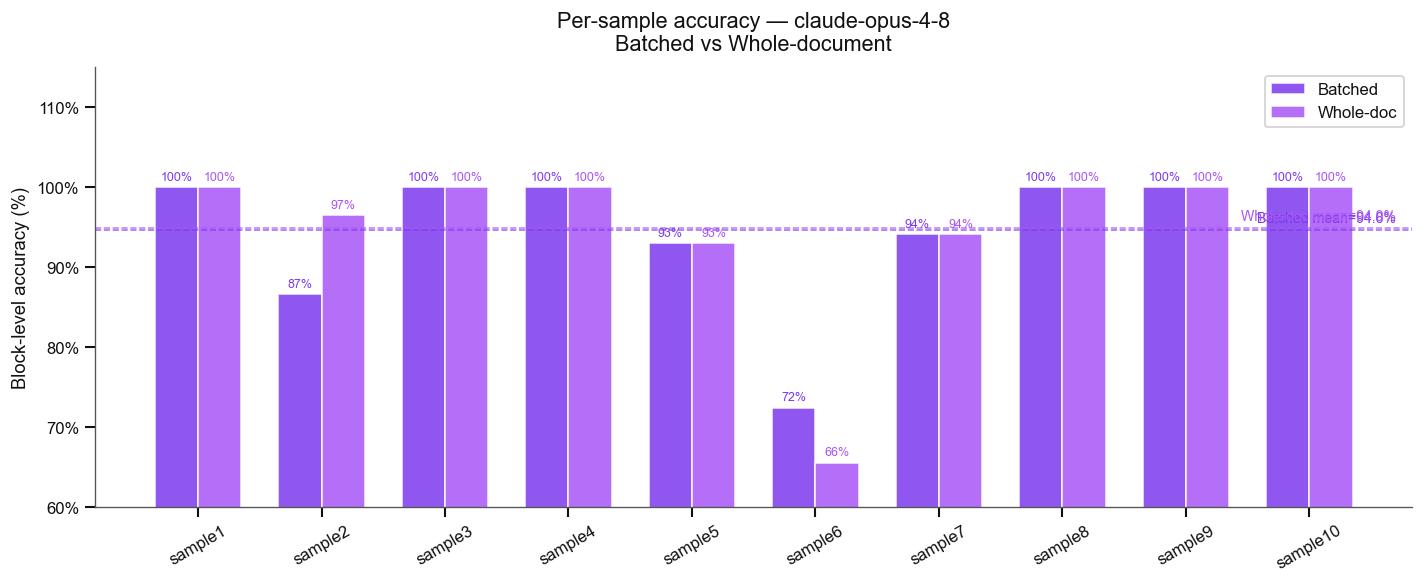

In [4]:
samples_ordered = df_b["sample"].tolist()
x = range(len(samples_ordered))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

acc_b = df_b.set_index("sample").loc[samples_ordered, "accuracy"] * 100
acc_w = df_w.set_index("sample").loc[samples_ordered, "accuracy"] * 100

bars_b = ax.bar([xi - w/2 for xi in x], acc_b, width=w,
                label="Batched", color=COLOR_BATCH, alpha=0.85, edgecolor="white")
bars_w = ax.bar([xi + w/2 for xi in x], acc_w, width=w,
                label="Whole-doc", color=COLOR_WHOLE, alpha=0.85, edgecolor="white")

for bar, v in zip(bars_b, acc_b):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{v:.0f}%", ha="center", va="bottom", fontsize=7.5, color=COLOR_BATCH)
for bar, v in zip(bars_w, acc_w):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{v:.0f}%", ha="center", va="bottom", fontsize=7.5, color=COLOR_WHOLE)

avg_b = acc_b.mean()
avg_w = acc_w.mean()
ax.axhline(avg_b, color=COLOR_BATCH, linestyle="--", linewidth=1.0, alpha=0.7)
ax.axhline(avg_w, color=COLOR_WHOLE, linestyle="--", linewidth=1.0, alpha=0.7)
ax.text(len(x) - 0.3, avg_b + 0.6, f"Batched mean={avg_b:.1f}%",
        ha="right", va="bottom", fontsize=8.5, color=COLOR_BATCH)
ax.text(len(x) - 0.3, avg_w + 0.6, f"Whole-doc mean={avg_w:.1f}%",
        ha="right", va="bottom", fontsize=8.5, color=COLOR_WHOLE)

ax.set_xticks(list(x))
ax.set_xticklabels(samples_ordered, rotation=30)
ax.set_ylim(60, 115)
ax.set_ylabel("Block-level accuracy (%)")
ax.set_title(f"Per-sample accuracy — {MODEL_NAME}\nBatched vs Whole-document", pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend(framealpha=0.9)
sns.despine(); plt.tight_layout(); plt.show()

## 3 — Confusion matrices

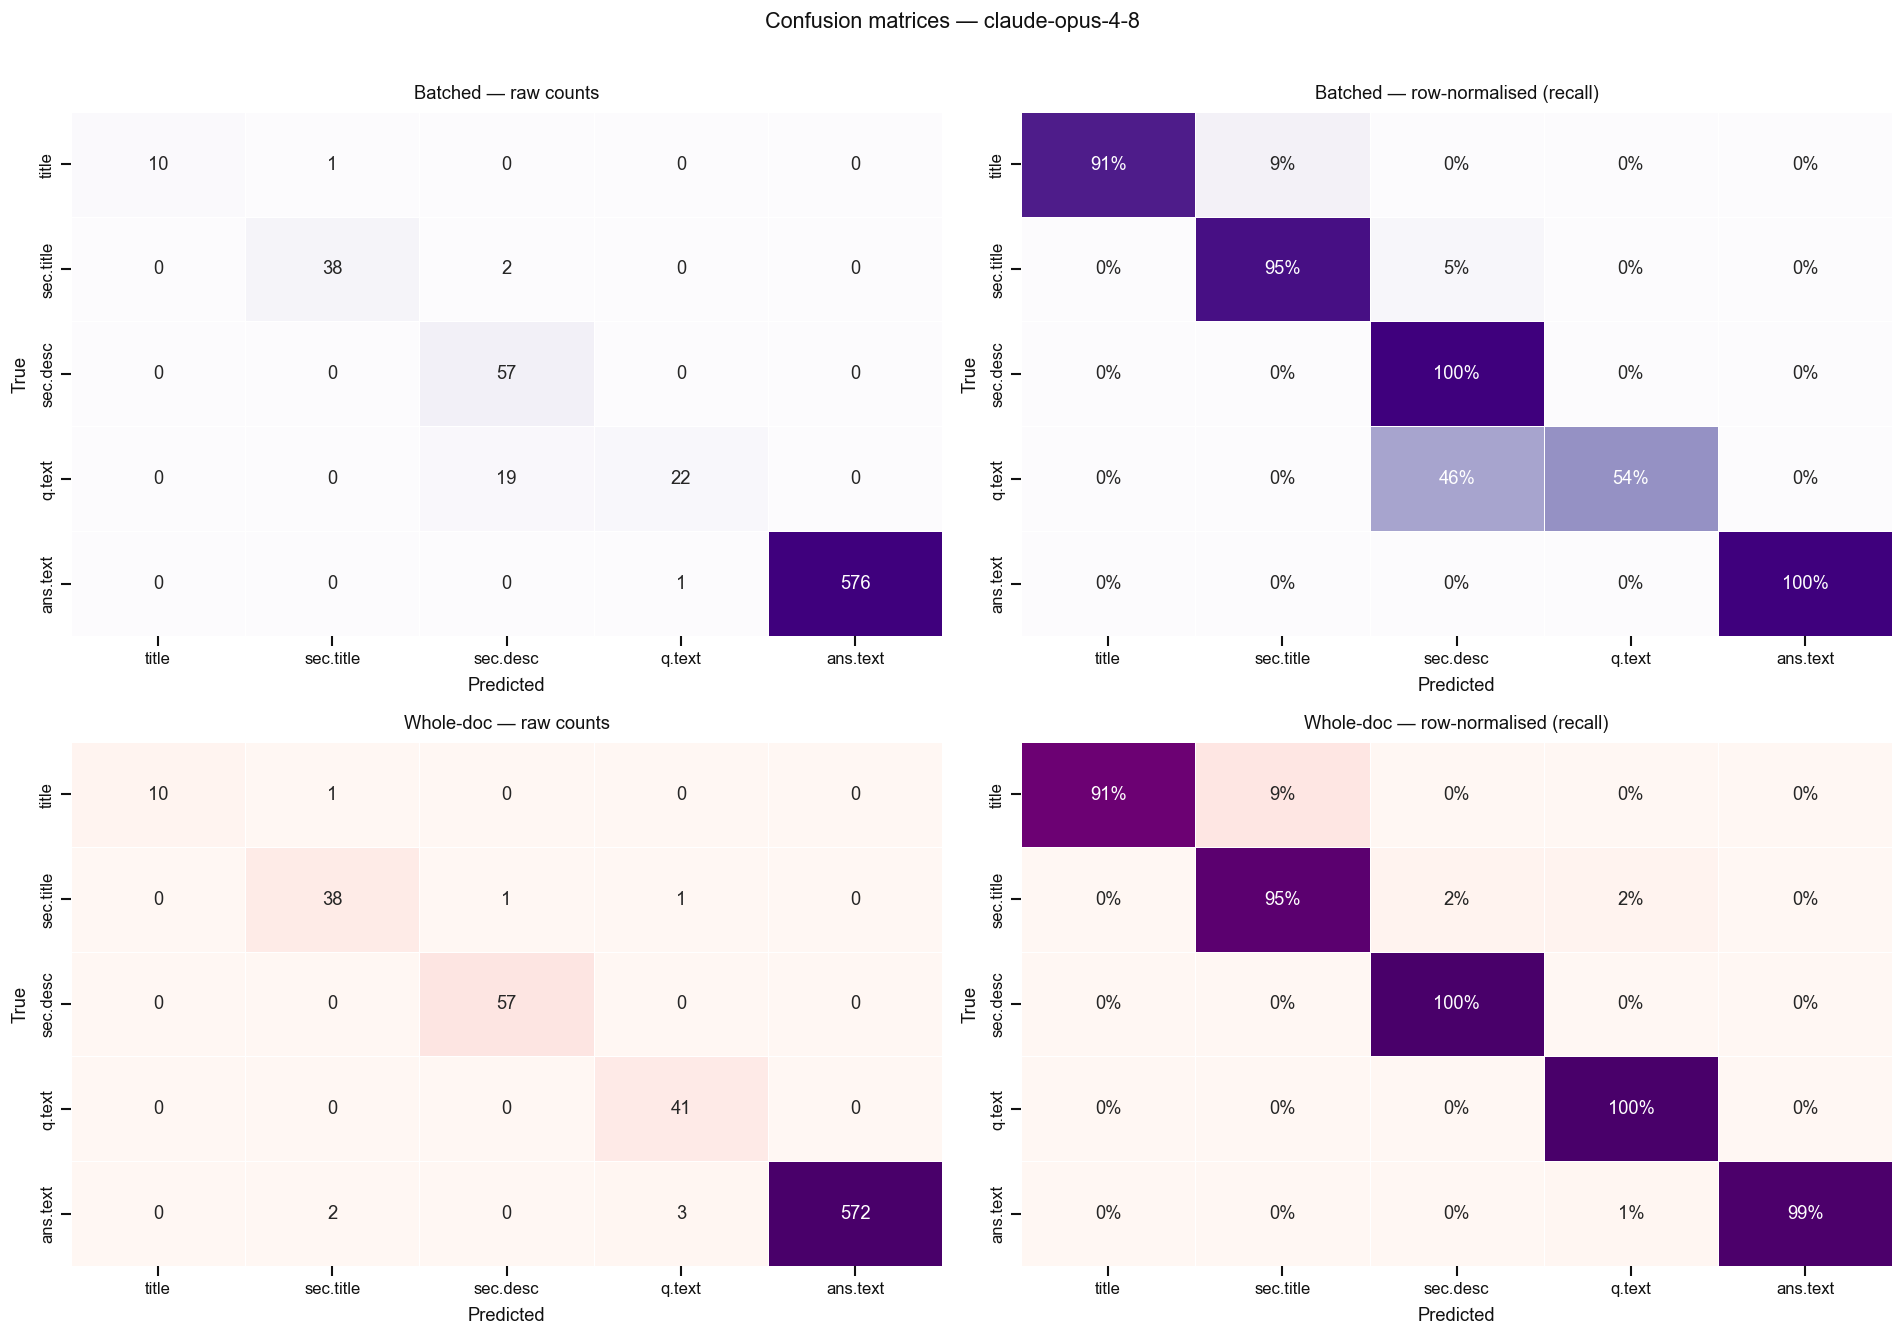

In [5]:
def conf_to_df(conf):
    m = pd.DataFrame(
        [[conf.get(t, {}).get(p, 0) for p in LABELS] for t in LABELS],
        index=SHORT, columns=SHORT)
    return m, m.div(m.sum(axis=1).replace(0, 1), axis=0)

mat_b, mat_bn = conf_to_df(conf_b)
mat_w, mat_wn = conf_to_df(conf_w)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for ax, mat, fmt, cmap, title in [
    (axes[0,0], mat_b,  "d",   CMAP_BATCH, "Batched — raw counts"),
    (axes[0,1], mat_bn, ".0%", CMAP_BATCH, "Batched — row-normalised (recall)"),
    (axes[1,0], mat_w,  "d",   CMAP_WHOLE, "Whole-doc — raw counts"),
    (axes[1,1], mat_wn, ".0%", CMAP_WHOLE, "Whole-doc — row-normalised (recall)"),
]:
    sns.heatmap(mat, annot=True, fmt=fmt, cmap=cmap, linewidths=0.6,
                linecolor="white", ax=ax, cbar=False,
                annot_kws={"size": 11},
                vmin=(0 if fmt == ".0%" else None),
                vmax=(1 if fmt == ".0%" else None))
    ax.set_title(title, pad=8, fontsize=11)
    ax.set_xlabel("Predicted", labelpad=6)
    ax.set_ylabel("True", labelpad=6)

plt.suptitle(f"Confusion matrices — {MODEL_NAME}", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 4 — Precision / Recall / F1 per label

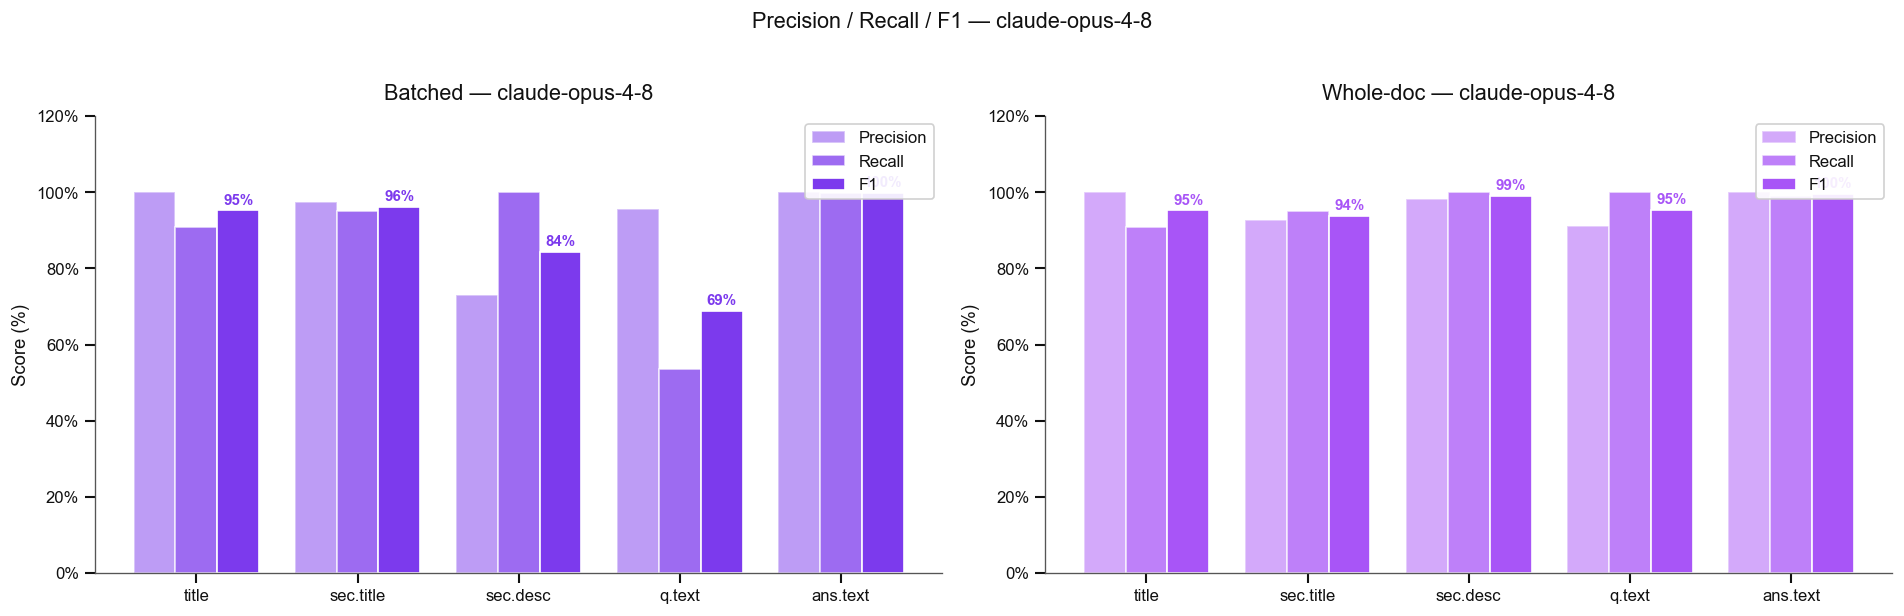

,precision_batch,recall_batch,f1_batch,precision_whole,recall_whole,f1_whole,f1_delta
label,,,,,,,
title,100.0%,90.9%,95.2%,100.0%,90.9%,95.2%,0.0%
section.title,97.4%,95.0%,96.2%,92.7%,95.0%,93.8%,-2.4%
section.description,73.1%,100.0%,84.4%,98.3%,100.0%,99.1%,14.7%
question.text,95.7%,53.7%,68.8%,91.1%,100.0%,95.3%,26.6%
answer.text,100.0%,99.8%,99.9%,100.0%,99.1%,99.6%,-0.3%


In [6]:
def compute_f1_rows(conf):
    rows = []
    for lbl in LABELS:
        tp = conf.get(lbl, {}).get(lbl, 0)
        fp = sum(conf.get(o, {}).get(lbl, 0) for o in LABELS if o != lbl)
        fn = sum(v for p, v in conf.get(lbl, {}).items() if p != lbl)
        support = tp + fn
        p_ = tp / (tp + fp) if (tp + fp) else 0.
        r_ = tp / support   if support  else 0.
        f1 = 2 * p_ * r_ / (p_ + r_) if (p_ + r_) else 0.
        rows.append({"label": lbl, "precision": p_, "recall": r_, "f1": f1, "support": support})
    return pd.DataFrame(rows)

df_f1_b = compute_f1_rows(conf_b)
df_f1_w = compute_f1_rows(conf_w)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, df_f1, color, cmap, title in [
    (axes[0], df_f1_b, COLOR_BATCH, CMAP_BATCH, f"Batched — {MODEL_NAME}"),
    (axes[1], df_f1_w, COLOR_WHOLE, CMAP_WHOLE, f"Whole-doc — {MODEL_NAME}"),
]:
    xi = range(len(LABELS))
    w  = 0.26
    ax.bar([i - w for i in xi], df_f1["precision"] * 100, width=w, label="Precision",
           color=color, alpha=0.5, edgecolor="white")
    ax.bar([i     for i in xi], df_f1["recall"]    * 100, width=w, label="Recall",
           color=color, alpha=0.75, edgecolor="white")
    bars = ax.bar([i + w for i in xi], df_f1["f1"] * 100, width=w, label="F1",
                  color=color, edgecolor="white")
    for bar, row in zip(bars, df_f1.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f"{row.f1*100:.0f}%", ha="center", va="bottom",
                fontsize=9, fontweight="bold", color=color)
    ax.set_xticks(list(xi)); ax.set_xticklabels(SHORT, fontsize=10)
    ax.set_ylim(0, 120); ax.set_ylabel("Score (%)")
    ax.set_title(title, pad=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.legend(loc="upper right", framealpha=0.9)
    sns.despine(ax=ax)

plt.suptitle(f"Precision / Recall / F1 — {MODEL_NAME}", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# Summary table
comb = df_f1_b.set_index("label")[["precision","recall","f1"]].rename(
       columns=lambda c: f"{c}_batch")
comb = comb.join(df_f1_w.set_index("label")[["precision","recall","f1"]].rename(
       columns=lambda c: f"{c}_whole"))
comb["f1_delta"] = comb["f1_whole"] - comb["f1_batch"]
comb.style.format("{:.1%}").background_gradient(subset=["f1_batch","f1_whole"], cmap="Purples")

## 5 — Mislabeled blocks

In [7]:
def print_error_breakdown(df_err, label):
    print(f"\n  {label}: {len(df_err)} mislabeled blocks")
    if df_err.empty:
        print("  No errors — perfect score!")
        return
    breakdown = (df_err.groupby(["true", "pred"])
                 .size().reset_index(name="count")
                 .sort_values("count", ascending=False))
    print(breakdown.to_string(index=False))

print_error_breakdown(errs_b, "Batched")
print_error_breakdown(errs_w, "Whole-doc")


  Batched: 26 mislabeled blocks
         true                pred  count
question.text section.description     19
     no_match         answer.text      3
section.title section.description      2
  answer.text       question.text      1
        title       section.title      1

  Whole-doc: 11 mislabeled blocks
         true                pred  count
  answer.text       question.text      3
     no_match       section.title      3
  answer.text       section.title      2
section.title       question.text      1
section.title section.description      1
        title       section.title      1


In [8]:
pd.set_option("display.max_colwidth", 100)

if not errs_b.empty:
    print("=== Batched errors ===")
    display(errs_b[["sample","page","true","pred","text"]])

if not errs_w.empty:
    print("\n=== Whole-doc errors ===")
    display(errs_w[["sample","page","true","pred","text"]])

=== Batched errors ===


,sample,page,true,pred,text
0,sample2,2,question.text,section.description,"This should include, where appropriate:"
1,sample2,2,question.text,section.description,the anticipated means for sharing and rationale for any restrictions on who may access the data
2,sample2,2,question.text,section.description,and under what conditions;
3,sample2,2,question.text,section.description,a timeline for sharing and preservation that addresses both the minimum length of time the data
4,sample2,2,question.text,section.description,will be available and any anticipated delay to data access after research findings are published;
5,sample2,2,question.text,section.description,"any special requirements for data sharing, for example, proprietary software needed to access"
6,sample2,2,question.text,section.description,"or interpret data, applicable policies, provisions, and licenses for re-use and re-distribution,..."
7,sample2,2,question.text,section.description,"for the production of derivatives, including guidance for how data and data products should be"
8,sample2,2,question.text,section.description,cited;
9,sample2,2,question.text,section.description,"any resources and capabilities (equipment, connections, systems, software, expertise, etc.)"



=== Whole-doc errors ===


,sample,page,true,pred,text
0,sample2,1,answer.text,question.text,"Roles & Responsibilities. For the proposed research, Director Samuel Stupp with help from the"
1,sample2,2,section.title,question.text,preservation;
2,sample2,4,answer.text,question.text,Data Repositories. Senior investigators typically archive relevant data using their own group se...
3,sample2,4,answer.text,question.text,"Data Volume. Generally, the volume of data generated by CBES researchers should not prohibit their"
4,sample2,5,section.title,section.description,data.
5,sample6,1,answer.text,section.title,"1. Types of data. The bulk of the data generated in this project will be 1, 2, 3, and 4"
6,sample6,1,no_match,section.title,2. Data and metadata standards. The PI’s research group will adopt the longstanding
7,sample6,1,answer.text,section.title,3. Policies for access and sharing. Interested parties will be able to request data and codes at
8,sample6,1,no_match,section.title,"4. Policies and provisions for re-use, re-distribution. Simulation data will in essence grow to"
9,sample6,1,no_match,section.title,5. Plans for archiving and preservation of access. Local data will be archived on the group’s
